# 03 · Splits, controles de leakage y baselines

**Pregunta:** ¿el dataset generado por `generate_queries.py` sirve para entrenar y evaluar un ranker?
Sirve si los splits no filtran información, si los modelos aprendidos superan a la regla exacta con
intervalos que no se solapan y si hay un umbral de "candidata clara" útil.

Todo el ajuste (early stopping, umbrales) se hace en **validación**. El test generado se evalúa
una sola vez al final, con todo congelado.

In [1]:
import sys, json, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import GroupKFold
from sklearn.metrics import brier_score_loss, roc_auc_score
from common import OUT_DIR, SEED
from generate_queries import FEATURES
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220, "display.max_columns", 40, "display.max_rows", 120)
Q = pd.read_parquet(OUT_DIR / "queries.parquet")
P = pd.read_parquet(OUT_DIR / "pairs.parquet").sort_values(["query_id", "candidate_tx_id"], ignore_index=True)
M = json.loads((OUT_DIR / "manifest.json").read_text())
print("generador", M["generator_version"], "| alias", M["aliases_version"], M["aliases_sha"], "| semilla", M["seed"])
print(len(Q), "consultas |", len(P), "pares |", len(FEATURES), "features")

generador 1.0.0 | alias 1.0.0 1f1717e40daed173 | semilla 42
93724 consultas | 253445 pares | 34 features


## Fase 4 · Splits
**Pregunta:** ¿cuántas consultas, pares y clientes hay por split, y respetan el corte por cliente y
el corte temporal?

In [2]:
sz = Q.groupby(["split", "subset"]).agg(consultas=("query_id", "size"), clientes=("customer_id", "nunique"),
                                        cand_media=("n_candidates", "mean"),
                                        sesion_desde=("session_ts", "min"), sesion_hasta=("session_ts", "max"))
sz["pares"] = P.groupby(["split", "subset"]).size()
print(sz.round(2).to_string())
print("\nsplit por plantilla (monto×comercio×fecha): plantillas reservadas =", len(M["template_holdout"]), "de 80")
print(Q.groupby(["split", "tpl_holdout"]).size().unstack().rename(columns={False: "vistas", True: "reservadas"}).to_string())

               consultas  clientes  cand_media        sesion_desde        sesion_hasta   pares
split subset                                                                                  
test  hard          1045       778        3.66 2026-01-01 05:47:35 2026-06-18 05:04:28    3824
      natural      10000      7354        2.58 2026-01-01 00:10:06 2026-06-18 05:39:20   25813
train hard         12000      9484        3.61 2023-08-16 08:39:32 2025-08-31 23:54:06   43371
      natural      60000     40931        2.54 2023-08-16 06:06:36 2025-08-31 23:59:16  152584
val   hard           679       550        3.64 2025-09-01 01:03:39 2025-12-31 21:09:10    2473
      natural      10000      7366        2.54 2025-09-01 00:12:59 2025-12-31 23:51:29   25380

split por plantilla (monto×comercio×fecha): plantillas reservadas = 16 de 80
tpl_holdout  vistas  reservadas
split                          
test           9093        1952
train         59485       12515
val            8765        1914


## Fase 4 · Controles de leakage

In [3]:
checks = {}
cs = Q.groupby("customer_id").split.nunique(); checks["clientes en >1 split"] = int((cs > 1).sum())
test_c = set(P.loc[P.split == "test", "candidate_tx_id"]); train_c = set(P.loc[P.split == "train", "candidate_tx_id"])
checks["candidate_tx_id de test presentes en train"] = len(test_c & train_c)
checks["candidate_tx_id de val presentes en train"] = len(set(P.loc[P.split == "val", "candidate_tx_id"]) & train_c)
pos = P.groupby("query_id").label.sum(); checks["consultas con nº positivos ≠ 1"] = int((pos != 1).sum())
checks["features prohibidas presentes"] = sorted({"is_fraud", "fraud_score", "label", "target_tx_id"} & set(FEATURES))
r = Q.groupby("split").session_ts.agg(["min", "max"])
checks["orden temporal train < val < test"] = bool(r.loc["train", "max"] < r.loc["val", "min"] and r.loc["val", "max"] < r.loc["test", "min"])
for k, v in checks.items(): print(f"{k:45s} {v}")

clientes en >1 split                          0
candidate_tx_id de test presentes en train    0
candidate_tx_id de val presentes en train     0
consultas con nº positivos ≠ 1                0
features prohibidas presentes                 []
orden temporal train < val < test             True


In [4]:
# ¿alguna feature ES el label? AUC univariada (sobre pares de train) y reglas deterministas
tr = P[P.split == "train"]
auc = pd.Series({f: roc_auc_score(tr.label, tr[f]) for f in FEATURES if tr[f].nunique() > 1})
auc = (auc - 0.5).abs().add(0.5).sort_values(ascending=False)
print("AUC univariada |máx|:", auc.head(8).round(3).to_dict())
print("P(label=1 | status_declined=1) =", tr.loc[tr.status_declined == 1, "label"].mean(),
      "| P(label=1 | status_reversed=1) =", tr.loc[tr.status_reversed == 1, "label"].mean())

AUC univariada |máx|: {'amt_gap_to_best': 0.885, 'amt_rank': 0.881, 'amt_log_ratio_abs': 0.83, 'amt_rel_diff': 0.83, 'amt_within_5': 0.819, 'amt_within_10': 0.813, 'amt_within_20': 0.809, 'recency_rank': 0.799}
P(label=1 | status_declined=1) = 0.0 | P(label=1 | status_reversed=1) = 0.0


**Interpretación (fase 4):** Los splits son disjuntos por cliente (0 clientes y 0 `candidate_tx_id` compartidos entre train y val/test) y temporales (sesiones de train hasta 2025-08-31, val de 2025-09 a 2025-12, test desde 2026-01-01). Cada consulta tiene exactamente 1 positivo y no hay features prohibidas. Ninguna feature es el label por sí sola: la de mayor AUC univariada es `amt_gap_to_best` (0,885). Hay una regla determinista **creada por el generador**: `Declined`/`Reversed` nunca son objetivo (P = 0), porque solo se eligen objetivos Approved/Pending. Es un supuesto de negocio razonable, pero el modelo lo aprende como verdad absoluta. El subconjunto hard de val/test es chico (679 y 1.045) porque los distractores con mismo comercio y monto ±10 % solo aparecen en el ~2 % del pool.

## Fase 5 · Modelos
Cuatro rankers, más "la más reciente" como referencia sin pistas:
1. **Regla exacta**: se queda con las candidatas cuyo monto coincide exactamente con el dicho y las ordena por
   fecha (más reciente primero). Si ninguna coincide, no devuelve nada (la objetivo cuenta como no encontrada).
2. **RuleRanker**: score escrito a mano (sin ajustar a los datos) con monto, fecha, comercio y estado, más softmax.
3. **Regresión logística** sobre pares, `class_weight="balanced"` y features estandarizadas.
4. **LightGBM lambdarank** agrupando por `query_id` (early stopping en validación).

Métricas por consulta: top-1, recall@3 y MRR. Los empates se rompen al azar con semilla 42 (la regla exacta
desempata por fecha). IC 95 % por bootstrap de consultas (B = 1000).

In [5]:
rng_tie = np.random.default_rng(SEED)
P["tie"] = rng_tie.random(len(P))

def ranks(df, score):
    """rank de la objetivo dentro de su consulta (1 = primera); NaN si el modelo no la devuelve."""
    d = df.assign(s=score).sort_values(["query_id", "s", "tie"], ascending=[True, False, True])
    d["r"] = d.groupby("query_id").cumcount() + 1
    out = d.loc[d.label == 1].set_index("query_id")
    return out.r.where(out.s > -np.inf)

def metrics(r):
    r = r.to_numpy(float)
    return {"top1": np.nan_to_num(r == 1), "r3": np.nan_to_num(r <= 3), "mrr": np.nan_to_num(1 / r)}

def boot(x, B=1000, seed=SEED):
    x = np.asarray(x, float); rr = np.random.default_rng(seed)
    idx = rr.integers(0, len(x), (B, len(x)))
    m = x[idx].mean(1); return x.mean(), *np.percentile(m, [2.5, 97.5])

def fmt(x):
    m, lo, hi = boot(x); return f"{m*100:5.1f} [{lo*100:4.1f}, {hi*100:4.1f}]"

def softmax_by_query(df, s, T=1.0):
    z = pd.Series(s / T, index=df.index); z = z - z.groupby(df.query_id).transform("max")
    e = np.exp(z); return (e / e.groupby(df.query_id).transform("sum")).to_numpy()

In [6]:
def score_exact(df):
    return np.where(df.amt_exact == 1, -df.days_since_tx, -np.inf)

def score_recency(df):
    return -df.days_since_tx.to_numpy()

def score_rule(df):
    """RuleRanker: pesos fijados a priori (no se ajustan con datos)."""
    s = np.zeros(len(df))
    has_a, has_d, has_m = df.amt_missing == 0, df.date_missing == 0, df.merch_missing == 0
    s += np.where(has_a, 4.0 * np.exp(-df.amt_rel_diff / 0.10), 0)          # monto: pesa más
    s += np.where(has_a & (df.amt_approx_flag == 0), 2.0 * df.amt_exact, 0)   # bonus si dijo el monto exacto
    s += np.where(has_d, 2.5 * np.exp(-df.date_days_to_range / 3.0), 0)       # fecha dicha
    s += 0.5 * np.exp(-df.days_since_tx / 30.0)                              # recencia débil
    s += np.where(has_m, 2.0 * df.merch_sim + 1.0 * df.cat_match + 1.0 * df.type_match, 0)
    s += np.where(df.cur_missing == 0, 0.5 * df.cur_match, 0)
    s -= 1.5 * df.status_declined + 1.0 * df.status_reversed                 # un rechazo no cobró
    return s

tr, va, te = (P[P.split == s].copy() for s in ["train", "val", "test"])
X = lambda d: d[FEATURES].to_numpy(float)

# Regresión logística
lr = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", C=1.0, max_iter=2000))
lr.fit(X(tr), tr.label)

# LightGBM lambdarank (grupos por consulta; early stopping en val)
def groups(d): return d.groupby("query_id", sort=False).size().to_numpy()
params = dict(objective="lambdarank", metric="ndcg", ndcg_eval_at=[1, 3], learning_rate=0.05, num_leaves=31,
              min_data_in_leaf=50, feature_fraction=0.9, bagging_fraction=0.8, bagging_freq=1, seed=SEED,
              deterministic=True, verbose=-1, num_threads=4)
dtr = lgb.Dataset(X(tr), tr.label, group=groups(tr), feature_name=FEATURES)
dva = lgb.Dataset(X(va), va.label, group=groups(va), reference=dtr)
gbm = lgb.train(params, dtr, 1000, valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False)])
print("LightGBM mejor iteración:", gbm.best_iteration)

SCORERS = {"más reciente (sin pistas)": score_recency, "1. regla exacta": score_exact, "2. RuleRanker": score_rule,
           "3. regresión logística": lambda d: lr.decision_function(X(d)),
           "4. LightGBM lambdarank": lambda d: gbm.predict(X(d), num_iteration=gbm.best_iteration)}

LightGBM mejor iteración: 188


## Resultados en validación (consultas naturales)

In [7]:
va_nat = va[va.subset == "natural"]; va_hard = va[va.subset == "hard"]
R = {}  # rank de la objetivo por modelo, para todo val
for name, f in SCORERS.items():
    R[name] = ranks(va, f(va))
def table(qids):
    rows = []
    for name in SCORERS:
        m = metrics(R[name].loc[qids])
        rows.append({"modelo": name, "top-1 %": fmt(m["top1"]), "recall@3 %": fmt(m["r3"]), "MRR ×100": fmt(m["mrr"])})
    return pd.DataFrame(rows).set_index("modelo")
qn = va_nat.query_id.unique(); qh = va_hard.query_id.unique()
print(f"VALIDACIÓN natural (n={len(qn)})"); print(table(qn).to_string())
print(f"\nVALIDACIÓN hard (n={len(qh)})"); print(table(qh).to_string())
cov_exact = (va_nat.groupby("query_id").amt_exact.max() == 1).mean()
print(f"\nla regla exacta devuelve alguna candidata en el {cov_exact*100:.1f} % de las consultas naturales")

VALIDACIÓN natural (n=10000)


                                      top-1 %           recall@3 %            MRR ×100
modelo                                                                                
más reciente (sin pistas)   70.9 [70.0, 71.8]    98.2 [98.0, 98.5]   84.1 [83.6, 84.6]
1. regla exacta             31.2 [30.3, 32.2]    31.2 [30.3, 32.2]   31.2 [30.3, 32.2]
2. RuleRanker               98.0 [97.7, 98.2]  100.0 [99.9, 100.0]   98.9 [98.8, 99.1]
3. regresión logística      98.4 [98.1, 98.6]  100.0 [99.9, 100.0]   99.2 [99.0, 99.3]
4. LightGBM lambdarank      98.7 [98.5, 98.9]   99.9 [99.9, 100.0]   99.3 [99.2, 99.4]

VALIDACIÓN hard (n=679)
                                      top-1 %           recall@3 %            MRR ×100
modelo                                                                                
más reciente (sin pistas)   56.6 [52.7, 60.2]    95.6 [94.0, 97.1]   75.4 [73.1, 77.5]
1. regla exacta             30.2 [26.7, 33.6]    30.2 [26.7, 33.6]   30.2 [26.7, 33.6]
2. RuleRanker     

**Interpretación:** En validación natural, el **RuleRanker escrito a mano, sin ajustar, ya logra 98,0 % top-1 [97,7–98,2] y 100 % recall@3**. LR (98,4 %) y LightGBM (98,7 % [98,5–98,9]) lo superan por solo 0,4–0,7 pp; el IC de LightGBM no se solapa con el del RuleRanker, pero la ganancia es marginal. La **regla exacta** se queda en 31,2 %: devuelve algo solo cuando el cliente da el monto exacto (31,2 % de las consultas) y ahí acierta el 100 %. Superarla con IC que no se solapan es trivial y no prueba que haga falta un modelo aprendido. En el subconjunto hard (mismo comercio y monto ±10 % presentes) la diferencia crece: LightGBM 96,5 % frente a 93,2 % del RuleRanker. Recall@3 es ≈ 100 % para todos porque casi no hay 4 candidatas.

## Desglose por tipo de ruido, país y banda de densidad (validación natural, top-1 % con IC 95 %)

In [8]:
qv = Q.set_index("query_id").loc[qn]
qv["densidad"] = pd.cut(qv.n_candidates, [0, 1, 2, 4, 7, 100], labels=["1", "2", "3-4", "5-7", "8+"])
show = ["1. regla exacta", "2. RuleRanker", "3. regresión logística", "4. LightGBM lambdarank"]
def breakdown(col):
    rows = []
    for k, idx in qv.groupby(col, observed=True).groups.items():
        row = {col: k, "n": len(idx)}
        for name in show:
            m, lo, hi = boot(metrics(R[name].loc[idx])["top1"], B=500)
            row[name.split(". ")[1]] = f"{m*100:5.1f} [{lo*100:4.1f},{hi*100:4.1f}]"
        rows.append(row)
    return pd.DataFrame(rows).set_index(col)
for col in ["noise_amount_mode", "noise_merchant_mode_eff", "noise_date_mode", "noise_currency_mode", "customer_country", "densidad"]:
    print(breakdown(col).to_string(), "\n")

                      n         regla exacta           RuleRanker  regresión logística  LightGBM lambdarank
noise_amount_mode                                                                                          
absent             1871      0.0 [ 0.0, 0.0]     91.2 [90.0,92.4]     92.8 [91.5,94.0]     93.9 [92.7,94.8]
exact              3118  100.0 [100.0,100.0]  100.0 [100.0,100.0]  100.0 [100.0,100.0]  100.0 [100.0,100.0]
rounded            4009      0.1 [ 0.0, 0.3]     99.8 [99.6,99.9]    99.8 [99.7,100.0]    99.9 [99.8,100.0]
wrong              1002      0.0 [ 0.0, 0.0]     97.1 [96.1,98.0]     98.1 [97.2,98.9]     99.0 [98.4,99.6] 

                            n       regla exacta           RuleRanker regresión logística  LightGBM lambdarank
noise_merchant_mode_eff                                                                                       
absent                   2942   31.9 [30.4,33.5]     96.9 [96.3,97.5]    96.9 [96.3,97.5]     97.5 [97.0,98.1]
category         

                    n       regla exacta          RuleRanker regresión logística LightGBM lambdarank
noise_date_mode                                                                                     
absent           2503   31.0 [29.2,32.8]    95.8 [95.0,96.6]    96.8 [96.1,97.5]    97.2 [96.6,97.9]
exact            1943   28.2 [26.2,30.1]   99.9 [99.7,100.0]   99.9 [99.7,100.0]   99.9 [99.8,100.0]
relative         4043   32.0 [30.5,33.4]    97.9 [97.5,98.4]    98.3 [98.0,98.7]    98.7 [98.4,99.1]
shifted          1511   33.4 [31.1,35.4]    99.1 [98.5,99.5]    99.2 [98.7,99.6]    99.5 [99.1,99.8] 

                        n       regla exacta         RuleRanker regresión logística LightGBM lambdarank
noise_currency_mode                                                                                    
absent               5946   31.7 [30.5,32.8]   97.9 [97.5,98.2]    98.4 [98.0,98.7]    98.8 [98.5,99.1]
present              4054   30.6 [29.2,31.9]   98.1 [97.6,98.5]    98.4 [98.1,98

                     n       regla exacta         RuleRanker regresión logística LightGBM lambdarank
customer_country                                                                                    
Argentina         1920   31.3 [29.4,33.4]   98.0 [97.4,98.5]    98.4 [97.9,98.9]    98.6 [98.1,99.1]
Colombia          3063   30.8 [29.3,32.2]   98.3 [97.9,98.7]    98.8 [98.4,99.1]    98.9 [98.6,99.3]
México            5017   31.5 [30.0,32.8]   97.7 [97.3,98.1]    98.2 [97.8,98.5]    98.6 [98.3,98.9] 

             n       regla exacta           RuleRanker  regresión logística  LightGBM lambdarank
densidad                                                                                        
1         2772   29.8 [28.3,31.3]  100.0 [100.0,100.0]  100.0 [100.0,100.0]  100.0 [100.0,100.0]
2         2937   32.4 [30.7,34.2]     98.5 [98.1,98.9]     98.8 [98.4,99.2]     98.9 [98.5,99.3]
3-4       3273   31.5 [29.8,33.1]     96.6 [95.9,97.2]     97.3 [96.7,97.8]     98.1 [97.6,98.6]
5-7     

In [9]:
# combinaciones más difíciles: sin monto (o equivocado) × comercio × fecha
qv["top1_lgbm"] = metrics(R["4. LightGBM lambdarank"].loc[qn])["top1"]
qv["top1_lr"] = metrics(R["3. regresión logística"].loc[qn])["top1"]
g = qv.groupby("template_id").agg(n=("top1_lgbm", "size"), lgbm=("top1_lgbm", "mean"), lr=("top1_lr", "mean"), cand=("n_candidates", "mean"))
print(g[g.n >= 50].sort_values("lgbm").head(10).round(3).to_string())

                              n   lgbm     lr   cand
template_id                                         
absent|absent|absent        132  0.727  0.697  2.735
absent|absent|relative      211  0.877  0.848  2.564
absent|category|absent      101  0.901  0.931  2.465
absent|fragment|absent       65  0.908  0.892  2.569
absent|name|absent          114  0.912  0.939  2.728
absent|name|relative        188  0.947  0.931  2.670
absent|descriptor|relative   87  0.954  0.920  2.874
absent|category|shifted      50  0.960  0.980  2.400
absent|absent|shifted        90  0.967  0.956  2.544
wrong|absent|absent          71  0.972  0.930  2.324


**Interpretación:** Con monto exacto o redondeado, todos los rankers con pistas aciertan ≥ 99,8 %. El error se concentra en consultas **sin monto** (RuleRanker 91,2 %, LightGBM 93,9 %) y en la plantilla sin ninguna pista (absent|absent|absent: 72,7 %, que es lo que da la recencia). País y moneda no cambian nada (diferencias < 0,6 pp, IC solapados). La densidad sí importa: con 1 candidata, 100 %; con 5–7, 95,5–96,8 %. La ventaja del modelo aprendido sobre el RuleRanker aparece justo donde hay densidad y pistas vagas (3–4 candidatas: 98,1 vs 96,6 %), pero esa región es chica.

## Calibración de la regresión logística
**Pregunta:** ¿las probabilidades sirven para decidir "candidata clara"? `class_weight="balanced"` sesga las
probabilidades hacia arriba, así que se compara el LR crudo con uno calibrado (sigmoide, CV de 5 folds
agrupados por cliente en train). Se evalúa a nivel de par y a nivel de consulta (probabilidad normalizada
del primero frente a si acierta).

Brier par a par — LR crudo: 0.0138 | LR calibrado: 0.0135 | prevalencia: 0.394 | Brier de predecir la prevalencia: 0.2388
Brier por consulta (P(top-1 correcto)) — crudo: 0.0109 | calibrado: 0.0102
ECE par a par crudo      0.0049
ECE par a par calibrado  0.0047
ECE consulta crudo       0.0091
ECE consulta calibrado   0.0056

bins de P(top-1 correcto), LR calibrado:
                                               p      y     n
b                                                            
(0.33938215878957567, 0.9969061221262115]  0.783  0.839  1000
(0.9969061221262115, 0.999995867429133]    1.000  1.000  1000
(0.999995867429133, 0.999999995053573]     1.000  1.000  1000
(0.999999995053573, 0.9999999999968812]    1.000  1.000  1000
(0.9999999999968812, 0.9999999999999996]   1.000  1.000  1009
(0.9999999999999996, 1.0]                  1.000  1.000  4991


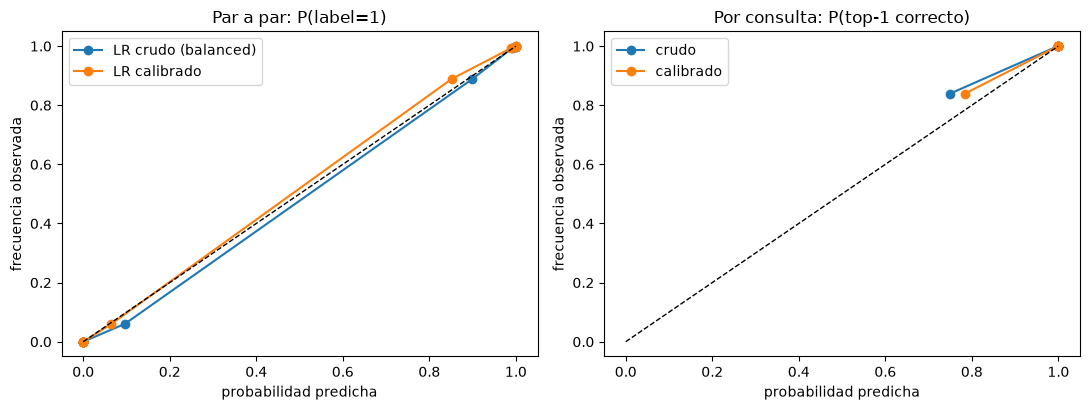

In [10]:
cv = list(GroupKFold(5).split(X(tr), tr.label, groups=tr.customer_id))
lr_cal = CalibratedClassifierCV(make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", C=1.0, max_iter=2000)),
                                method="sigmoid", cv=cv).fit(X(tr), tr.label)
pv_raw = lr.predict_proba(X(va_nat))[:, 1]; pv_cal = lr_cal.predict_proba(X(va_nat))[:, 1]
print("Brier par a par — LR crudo:", round(brier_score_loss(va_nat.label, pv_raw), 4),
      "| LR calibrado:", round(brier_score_loss(va_nat.label, pv_cal), 4),
      "| prevalencia:", round(va_nat.label.mean(), 3), "| Brier de predecir la prevalencia:", round(brier_score_loss(va_nat.label, np.full(len(va_nat), va_nat.label.mean())), 4))

def top1_conf(df, p):
    """probabilidad normalizada del primero, margen sobre el segundo y acierto, por consulta."""
    d = df[["query_id", "label", "tie"]].assign(p=p)
    d["pn"] = d.p / d.groupby("query_id").p.transform("sum")
    d = d.sort_values(["query_id", "pn", "tie"], ascending=[True, False, True])
    first = d.groupby("query_id").head(1).set_index("query_id")
    second = d.groupby("query_id").nth(1).set_index("query_id").pn
    return pd.DataFrame({"conf": first.pn, "p_raw": first.p, "margin": first.pn - second.reindex(first.index).fillna(0),
                         "ok": first.label})

C_raw, C_cal = top1_conf(va_nat, pv_raw), top1_conf(va_nat, pv_cal)
print("Brier por consulta (P(top-1 correcto)) — crudo:", round(brier_score_loss(C_raw.ok, C_raw.conf), 4),
      "| calibrado:", round(brier_score_loss(C_cal.ok, C_cal.conf), 4))
def ece(y, p, bins=10):
    b = pd.qcut(p, bins, duplicates="drop"); d = pd.DataFrame({"y": y, "p": p, "b": b})
    g = d.groupby("b", observed=True).agg(p=("p", "mean"), y=("y", "mean"), n=("y", "size"))
    return float((g.n * (g.p - g.y).abs()).sum() / g.n.sum()), g
for nm, yy, pp in [("par a par crudo", va_nat.label, pv_raw), ("par a par calibrado", va_nat.label, pv_cal),
                   ("consulta crudo", C_raw.ok, C_raw.conf), ("consulta calibrado", C_cal.ok, C_cal.conf)]:
    e, g = ece(np.asarray(yy), np.asarray(pp)); print(f"ECE {nm:20s} {e:.4f}")
print("\nbins de P(top-1 correcto), LR calibrado:"); print(ece(C_cal.ok.to_numpy(), C_cal.conf.to_numpy())[1].round(3).to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for p, lab in [(pv_raw, "LR crudo (balanced)"), (pv_cal, "LR calibrado")]:
    fy, fx = calibration_curve(va_nat.label, p, n_bins=10, strategy="quantile"); ax[0].plot(fx, fy, "o-", label=lab)
for C, lab in [(C_raw, "crudo"), (C_cal, "calibrado")]:
    fy, fx = calibration_curve(C.ok, C.conf.clip(0, 1), n_bins=10, strategy="quantile"); ax[1].plot(fx, fy, "o-", label=lab)
for a, t in zip(ax, ["Par a par: P(label=1)", "Por consulta: P(top-1 correcto)"]):
    a.plot([0, 1], [0, 1], "k--", lw=1); a.set_title(t); a.set_xlabel("probabilidad predicha"); a.set_ylabel("frecuencia observada"); a.legend()
plt.tight_layout(); plt.show()

**Interpretación:** Con un 39 % de positivos por par (conjuntos de 2–3 candidatas), `class_weight="balanced"` apenas descalibra. Brier por par: 0,0138 crudo, 0,0135 calibrado (predecir la prevalencia da 0,239). Por consulta, el ECE baja de 0,009 a 0,006 al calibrar. La tabla de bins muestra el problema de fondo: el 90 % de las consultas tiene P(top-1) ≈ 1 y acierta siempre, y toda la incertidumbre está en el decil inferior (predicho 0,78, observado 0,84; levemente subconfiado). Las probabilidades sirven, pero solo tienen algo que decidir en ~10 % de los casos.

## Curva de cobertura: % de consultas resueltas sin preguntar vs precisión
La consulta se resuelve sin preguntar si la confianza del primero ≥ τ **y** su margen sobre el segundo ≥ δ.
τ y δ se eligen en validación. La confianza es la probabilidad normalizada dentro de la consulta: LR calibrado,
y softmax del score para RuleRanker y LightGBM (temperatura ajustada en val por log-loss de la objetivo).

temperaturas: {'RuleRanker': 0.3, 'LightGBM': 0.75}


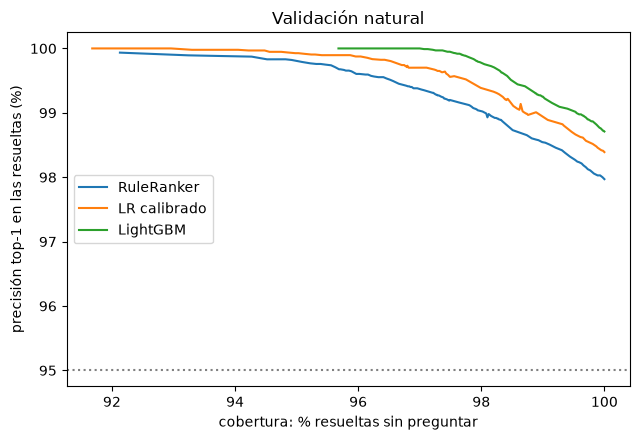

      modelo  precisión objetivo    τ   δ  cobertura %  precisión %
  RuleRanker                0.95 0.00 0.0        100.0        97.97
  RuleRanker                0.98 0.26 0.0         99.9        98.03
  RuleRanker                0.99 0.47 0.1         98.0        99.02
LR calibrado                0.95 0.00 0.0        100.0        98.39
LR calibrado                0.98 0.00 0.0        100.0        98.39
LR calibrado                0.99 0.52 0.0         98.9        99.01
    LightGBM                0.95 0.00 0.0        100.0        98.71
    LightGBM                0.98 0.00 0.0        100.0        98.71
    LightGBM                0.99 0.49 0.0         99.5        99.01
top-1 sin umbral: {'RuleRanker': np.float64(98.0), 'LR calibrado': np.float64(98.4), 'LightGBM': np.float64(98.7)}


In [11]:
def fit_T(df, s):
    best = None
    for T in [0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5]:
        pn = softmax_by_query(df, s, T); ll = -np.log(np.clip(pn[df.label.to_numpy() == 1], 1e-12, 1)).mean()
        best = min(best or (ll, T), (ll, T))
    return best[1]
s_rule_va, s_gbm_va = score_rule(va_nat).to_numpy(), SCORERS["4. LightGBM lambdarank"](va_nat)
T_rule, T_gbm = fit_T(va_nat, s_rule_va), fit_T(va_nat, s_gbm_va)
CONF = {"RuleRanker": top1_conf(va_nat, softmax_by_query(va_nat, s_rule_va, T_rule)),
        "LR calibrado": C_cal,
        "LightGBM": top1_conf(va_nat, softmax_by_query(va_nat, s_gbm_va, T_gbm))}
print("temperaturas:", {"RuleRanker": T_rule, "LightGBM": T_gbm})

def coverage_curve(C, deltas=(0, 0.1, 0.2, 0.3, 0.5)):
    rows = []
    for dlt in deltas:
        for tau in np.linspace(0, 0.99, 100):
            m = (C.conf >= tau) & (C.margin >= dlt)
            if m.sum() >= 30: rows.append((dlt, tau, m.mean(), C.ok[m].mean(), m.sum()))
    return pd.DataFrame(rows, columns=["delta", "tau", "cobertura", "precision", "n"])
fig, ax = plt.subplots(figsize=(6.5, 4.5)); OP = []
for name, C in CONF.items():
    cc = coverage_curve(C); env = cc.sort_values("cobertura").groupby("cobertura").precision.max()
    ax.plot(env.index * 100, env.values * 100, label=name)
    for target in (0.95, 0.98, 0.99):
        ok = cc[cc.precision >= target]
        if len(ok):
            b = ok.sort_values(["cobertura", "tau"], ascending=[False, True]).iloc[0]
            OP.append({"modelo": name, "precisión objetivo": target, "τ": round(b.tau, 2), "δ": b.delta,
                       "cobertura %": round(b.cobertura * 100, 1), "precisión %": round(b.precision * 100, 2)})
ax.set_xlabel("cobertura: % resueltas sin preguntar"); ax.set_ylabel("precisión top-1 en las resueltas (%)")
ax.axhline(95, color="grey", ls=":"); ax.legend(); ax.set_title("Validación natural"); plt.tight_layout(); plt.show()
OP = pd.DataFrame(OP); print(OP.to_string(index=False))
acc_all = {k: round(C.ok.mean() * 100, 1) for k, C in CONF.items()}; print("top-1 sin umbral:", acc_all)

**Interpretación:** La curva de cobertura casi no tiene rango útil. Sin umbral, los tres modelos ya superan el 95 % y el 98 % de precisión con el 100 % de cobertura (τ = 0). Para 99 % de precisión basta con preguntar en el 0,5–2 % de los casos (cobertura: LightGBM 99,5 %, LR 98,9 %, RuleRanker 98,0 %). Con la distribución de pistas simulada, el loop de aclaración se activaría en ~1–2 % de las sesiones. No hace falta un modelo aprendido para elegir ese umbral: el RuleRanker con softmax da una curva equivalente.

## Generalización a plantillas de ruido no vistas
**Pregunta:** si el generador cambia, ¿el modelo se degrada? (a) Se reentrena sin las 16 plantillas reservadas
(monto×comercio×fecha) y se compara en validación entre plantillas vistas y no vistas. (b) Se reentrena sin
ningún caso de monto **equivocado** y se mide en esos casos.

In [12]:
def fit_models(d):
    m_lr = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000)).fit(X(d), d.label)
    ds = lgb.Dataset(X(d), d.label, group=groups(d), feature_name=FEATURES)
    m_gbm = lgb.train(params, ds, gbm.best_iteration)
    return {"LR": lambda z: m_lr.decision_function(X(z)), "LightGBM": lambda z: m_gbm.predict(X(z))}
exp = []
full = {"LR": SCORERS["3. regresión logística"], "LightGBM": SCORERS["4. LightGBM lambdarank"]}
noTpl = fit_models(tr[~tr.tpl_holdout])
noWrong = fit_models(tr[~tr.noise_params.str.contains('"amount_mode": "wrong"')])
wrong_q = set(Q.loc[Q.noise_amount_mode == "wrong", "query_id"])
for mdl in ["LR", "LightGBM"]:
    for label, qids in [("plantillas vistas", va_nat[~va_nat.tpl_holdout].query_id.unique()),
                        ("plantillas NO vistas", va_nat[va_nat.tpl_holdout].query_id.unique())]:
        sub = va[va.query_id.isin(qids)]
        exp.append({"modelo": mdl, "evaluación": label, "n": len(qids),
                    "entrenado con todo": fmt(metrics(ranks(sub, full[mdl](sub)))["top1"]),
                    "entrenado sin plantillas reservadas": fmt(metrics(ranks(sub, noTpl[mdl](sub)))["top1"])})
    sub = va_nat[va_nat.query_id.isin(wrong_q)]
    exp.append({"modelo": mdl, "evaluación": "monto equivocado", "n": sub.query_id.nunique(),
                "entrenado con todo": fmt(metrics(ranks(sub, full[mdl](sub)))["top1"]),
                "entrenado sin plantillas reservadas": "—", "entrenado sin monto equivocado": fmt(metrics(ranks(sub, noWrong[mdl](sub)))["top1"])})
print(pd.DataFrame(exp).fillna("—").to_string(index=False))

  modelo           evaluación    n entrenado con todo entrenado sin plantillas reservadas entrenado sin monto equivocado
      LR    plantillas vistas 8216  98.3 [98.0, 98.6]                   98.3 [98.0, 98.6]                              —
      LR plantillas NO vistas 1784  98.9 [98.4, 99.3]                   98.9 [98.4, 99.4]                              —
      LR     monto equivocado 1002  98.1 [97.2, 98.8]                                   —              97.5 [96.4, 98.4]
LightGBM    plantillas vistas 8216  98.6 [98.3, 98.8]                   98.4 [98.1, 98.7]                              —
LightGBM plantillas NO vistas 1784  99.3 [98.8, 99.7]                   99.1 [98.7, 99.5]                              —
LightGBM     monto equivocado 1002  99.0 [98.3, 99.6]                                   —              97.4 [96.4, 98.2]


**Interpretación:** No se observa degradación al quitar plantillas del entrenamiento: las no vistas dan igual o mejor (LR 98,9 %, LightGBM 99,1–99,3 %) porque combinan modos que el modelo sí vio por separado. En cambio, entrenar sin ningún monto equivocado baja el top-1 en esos casos de 99,0 % a 97,4 % (LightGBM) y de 98,1 % a 97,5 % (LR), con IC que se tocan. Es una caída de ~1–2 pp: el modelo depende algo de haber visto ese tipo de error. El generador debería cubrir todos los modos de error que esperemos en producción.

## Importancia de features (LightGBM, ganancia) y coeficientes (LR)

In [13]:
imp = pd.Series(gbm.feature_importance("gain"), index=FEATURES).sort_values(ascending=False)
coef = pd.Series(lr[-1].coef_[0], index=FEATURES)
print(pd.DataFrame({"gain %": (imp / imp.sum() * 100).round(1), "coef LR (std)": coef.reindex(imp.index).round(2)}).head(15).to_string())

                    gain %  coef LR (std)
amt_gap_to_best       49.5         -16.56
date_days_to_range    16.5         -14.25
days_since_tx         10.9          -0.78
amt_missing            6.4          -0.76
amt_log_ratio_abs      2.5          -4.60
amt_rank               2.0          -4.35
date_in_range          1.4           0.79
merch_sim              1.1           0.65
date_range_width       1.0          -0.28
amt_within_5           0.9          -0.03
date_is_relative       0.8          -1.39
cat_match              0.7           2.84
type_hint_missing      0.7           2.00
amt_approx_flag        0.7           0.20
cat_hint_missing       0.6           3.71


**Interpretación:** El modelo aprende lo esperado: distancia de monto al mejor candidato (49,5 % de la ganancia), distancia a la fecha dicha (16,5 %) y recencia (10,9 %). La recencia es en parte un **artefacto del generador**: la sesión cae 0–30 días después de la objetivo dentro de una ventana de 60, así que la objetivo tiende a ser de las más recientes. El comercio pesa poco (similitud 1,1 %, categoría 0,7 %) porque solo el 35 % de las candidatas tiene comercio y con monto casi nunca hace falta.

## Test generado (una sola evaluación, todo congelado)
Modelos, temperatura y umbrales fijados en validación. Se reporta para confirmar que no hubo sobreajuste
a validación; no se usa para decidir nada.

In [14]:
te_nat = te[te.subset == "natural"]; qt = te_nat.query_id.unique()
rows = []
for name, f in SCORERS.items():
    m = metrics(ranks(te_nat, f(te_nat)))
    rows.append({"modelo": name, "top-1 %": fmt(m["top1"]), "recall@3 %": fmt(m["r3"]), "MRR ×100": fmt(m["mrr"])})
print(f"TEST natural (n={len(qt)})"); print(pd.DataFrame(rows).set_index("modelo").to_string())
op = OP[(OP.modelo == "LR calibrado") & (OP["precisión objetivo"] == 0.95)].iloc[0]
Ct = top1_conf(te_nat, lr_cal.predict_proba(X(te_nat))[:, 1]); mt = (Ct.conf >= op["τ"]) & (Ct.margin >= op["δ"])
print(f"\nLR calibrado con τ={op['τ']}, δ={op['δ']} (fijados en val para 95 %): cobertura test {mt.mean()*100:.1f} %, "
      f"precisión {Ct.ok[mt].mean()*100:.2f} % (n={mt.sum()})")
te_hard = te[te.subset == "hard"]
print(f"TEST hard (n={te_hard.query_id.nunique()}): top-1 LightGBM {fmt(metrics(ranks(te_hard, SCORERS['4. LightGBM lambdarank'](te_hard)))['top1'])},"
      f" regla exacta {fmt(metrics(ranks(te_hard, score_exact(te_hard)))['top1'])}, RuleRanker {fmt(metrics(ranks(te_hard, score_rule(te_hard)))['top1'])}")

TEST natural (n=10000)
                                      top-1 %            recall@3 %            MRR ×100
modelo                                                                                 
más reciente (sin pistas)   71.2 [70.3, 72.1]     98.3 [98.0, 98.5]   84.2 [83.7, 84.7]
1. regla exacta             30.1 [29.1, 31.0]     30.1 [29.1, 31.0]   30.1 [29.1, 31.0]
2. RuleRanker               97.8 [97.5, 98.0]   100.0 [99.9, 100.0]   98.8 [98.7, 99.0]
3. regresión logística      98.2 [97.9, 98.5]   100.0 [99.9, 100.0]   99.1 [98.9, 99.2]
4. LightGBM lambdarank      98.5 [98.3, 98.8]  100.0 [100.0, 100.0]   99.2 [99.1, 99.4]

LR calibrado con τ=0.0, δ=0.0 (fijados en val para 95 %): cobertura test 100.0 %, precisión 98.19 % (n=10000)
TEST hard (n=1045): top-1 LightGBM  94.7 [93.4, 96.1], regla exacta  31.7 [28.8, 34.5], RuleRanker  91.3 [89.6, 92.9]


**Interpretación:** El test natural reproduce la validación (RuleRanker 97,8 %, LR 98,2 %, LightGBM 98,5 %; recall@3 100 %): no hubo sobreajuste a validación. El umbral elegido en val para 95 % (τ = δ = 0) da 98,2 % de precisión con 100 % de cobertura en test. En test hard, LightGBM (94,7 %) supera al RuleRanker (91,3 %) por 3,4 pp con IC que no se solapan: es la única zona donde aprender aporta algo medible.

## Veredicto de la fase 5
- **Criterio VIABLE:** la ambigüedad natural es chica (72 % de las consultas tiene ≥ 2 candidatas, pero con monto ±10 % solo el 9,8 % queda empatada). Los modelos superan a la regla exacta con IC que no se solapan (98,7 % frente a 31,2 %), pero solo porque esa regla falla por diseño cuando el monto no es exacto. La curva de cobertura no deja un umbral útil: ya a τ = 0 la precisión es del 98 %.
- **Criterio TRIVIAL:** la regla exacta logra el 100 % cuando el cliente da el monto exacto, y una regla escrita a mano que tolera pistas vagas (RuleRanker) logra el 98,0 % top-1 y el 100 % recall@3 con la mezcla de pistas simulada. Se cumple en espíritu.
- **Veredicto: TRIVIAL.** Usar RuleRanker (o LR calibrado, si se quiere una probabilidad interpretable) y dedicar el esfuerzo al loop de aclaración, a la extracción de pistas y al set de test escrito a mano. El dataset generado sirve para **evaluar** el ranker y fijar el umbral, no para justificar un modelo aprendido complejo.